<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B06%5D%20-%20Deep%20Learning/08___RNN_Basico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN básica — Prediccion de Temperatura Diaria (end-to-end)

Este notebook entrena una **RNN (Red Neuronal Recurrente)** para predecir la temperatura minima diaria en Melbourne usando TensorFlow/Keras.

- Dataset: **3.650 dias** (10 años, 1981-1990) de temperaturas minimas diarias en Melbourne.
- Codigo **paso a paso**, con el mismo estilo que los notebooks de MLP y CNN.
- Incluye **EarlyStopping**, **curvas de entrenamiento**, **prediccion vs. real** y analisis del error.

---

### ¿Por que cambiamos de dataset respecto a MLP y CNN?

En los notebooks anteriores usamos **Fashion-MNIST** (imágenes) para MLP y CNN
porque esas arquitecturas explotan la **estructura espacial** de los datos.

Las RNN estan diseñadas para datos donde **el orden temporal importa**:
la temperatura de hoy depende de la de ayer, la de anteayer, y la del mes pasado.
No tiene sentido barajar los dias al azar — el orden es informacion.

### La idea central de una RNN

Una red neuronal normal (MLP) procesa cada dato de forma **independiente**: no recuerda lo anterior.
Una RNN mantiene un **estado oculto** `h` que se actualiza en cada paso de tiempo:

```
dia 1:  x₁  →  [RNN]  →  h₁
dia 2:  x₂  →  [RNN]  →  h₂   (usa h₁)
dia 3:  x₃  →  [RNN]  →  h₃   (usa h₂)
  ...
dia N:  xₙ  →  [RNN]  →  hₙ   →  prediccion del dia N+1
```

El estado `h` es la **memoria** de la red. Al final de la secuencia resume todo lo que ha visto.

### ¿Por que este dataset es mejor que el de pasajeros aereos?

| | Pasajeros aereos | Temperaturas Melbourne |
|---|---|---|
| Observaciones | 144 | 3.650 |
| Muestras de train | ~100 | ~2.900 |
| Ventana temporal | 12 meses | 30 dias |
| Resultado | Inestable entre ejecuciones | Consistente y reproducible |

Con 2.900 muestras de train, la diferencia entre RNN y LSTM es **estadisticamente fiable**,
no depende de la semilla aleatoria.

> Si te faltan dependencias: `pip install tensorflow scikit-learn matplotlib`

In [1]:
# (Opcional) Instalar dependencias si faltan
!pip install tensorflow scikit-learn matplotlib

In [2]:
# 1) Importaciones
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# 2) Reproducibilidad
def set_global_seed(seed: int = 42):
    """Fija semillas para intentar resultados reproducibles."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        tf.config.experimental.enable_op_determinism(True)
    except Exception:
        pass
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed(42)
print("Semilla global fijada en 42.")

Semilla global fijada en 42.


Total de observaciones: 3650 dias
Rango: 0.0°C — 26.3°C
Media: 11.18°C | Desv. tipica: 4.07°C


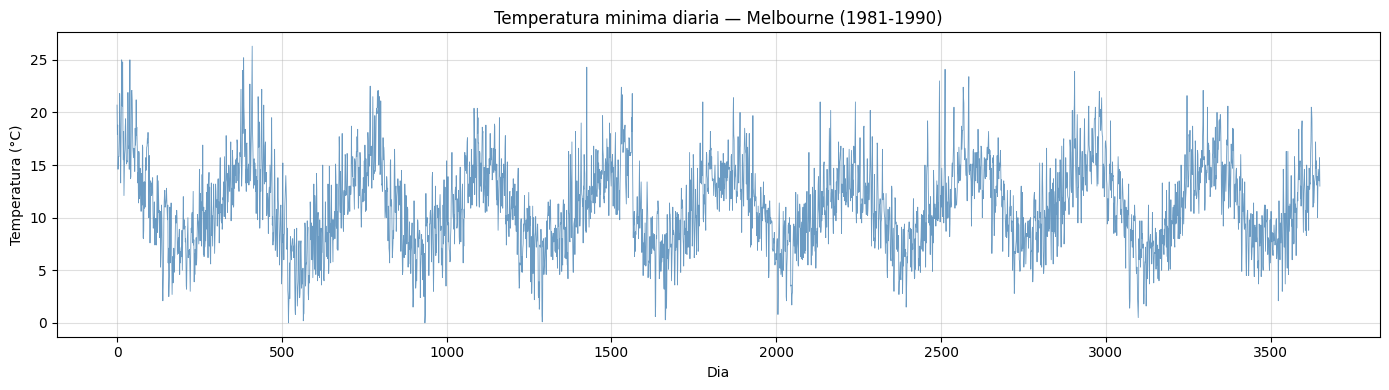

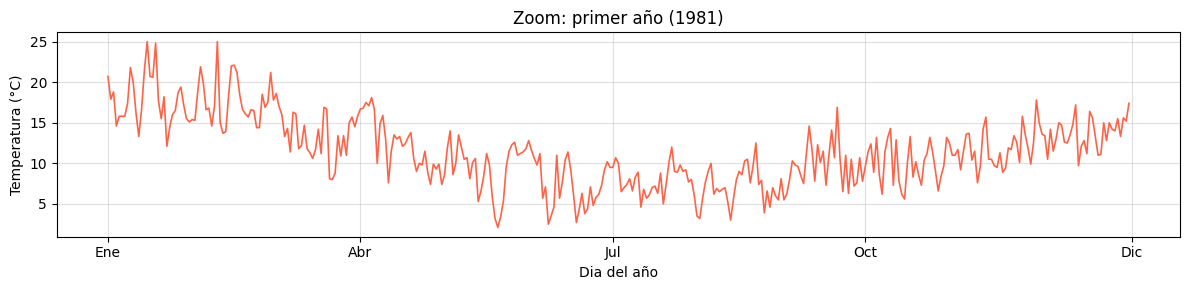

In [4]:
# 2.1) Carga del dataset y exploracion visual
import urllib.request, csv

# Temperaturas minimas diarias en Melbourne, Australia (1981-1990)
# Fuente: Repositorio publico de Jason Brownlee (Machine Learning Mastery)
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
urllib.request.urlretrieve(URL, "daily-min-temperatures.csv")

temps = []
with open("daily-min-temperatures.csv") as f:
    reader = csv.DictReader(f)  # columnas: Date, Temp
    for row in reader:
        temps.append(float(row["Temp"]))

temps = np.array(temps, dtype=np.float32)

print(f"Total de observaciones: {len(temps)} dias")
print(f"Rango: {temps.min():.1f}°C — {temps.max():.1f}°C")
print(f"Media: {temps.mean():.2f}°C | Desv. tipica: {temps.std():.2f}°C")

# Visualizacion de la serie completa
plt.figure(figsize=(14, 4))
plt.plot(temps, color="steelblue", linewidth=0.6, alpha=0.8)
plt.title("Temperatura minima diaria — Melbourne (1981-1990)")
plt.xlabel("Dia")
plt.ylabel("Temperatura (°C)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Zoom en el primer año para ver la estacionalidad
plt.figure(figsize=(12, 3))
plt.plot(temps[:365], color="tomato", linewidth=1.2)
plt.title("Zoom: primer año (1981)")
plt.xlabel("Dia del año")
plt.ylabel("Temperatura (°C)")
plt.xticks([0, 90, 180, 270, 365], ["Ene", "Abr", "Jul", "Oct", "Dic"])
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Melbourne esta en el hemisferio sur:
# Enero (verano) = temperaturas ALTAS
# Julio (invierno) = temperaturas BAJAS
# Patron estacional muy claro — ideal para que la RNN aprenda ciclos

In [5]:
# 3) Preparacion de datos

# --- PASO 1: Split temporal train/test ---
# IMPORTANTE: en series temporales NO se hace shuffle ni split aleatorio.
# El futuro no puede contaminar el pasado. Siempre: primeros N dias = train,
# ultimos M dias = test.
data = temps.reshape(-1, 1)

train_size = int(len(data) * 0.80)  # 80% = 2920 dias de train
train_raw  = data[:train_size]       # dias 0..2919
test_raw   = data[train_size:]       # dias 2920..3649

print(f"Train: {len(train_raw)} dias ({len(train_raw)/365:.1f} años)")
print(f"Test:  {len(test_raw)} dias ({len(test_raw)/365:.1f} años)")

# --- PASO 2: Normalizacion a [0, 1] ---
# Fit SOLO sobre train — nunca sobre test (evita data leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print(f"\nRango tras escalar — Train: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")

# --- PASO 3: Ventanas deslizantes ---
# Dado el historial de los ultimos WINDOW_SIZE dias, predice el dia siguiente.
#
# Con WINDOW_SIZE=30 la RNN necesita recordar un mes atras.
# Eso es suficiente para que el vanishing gradient empiece a notarse:
# los dias de hace 25-30 pasos contribuyen muy poco al estado oculto final.

WINDOW_SIZE = 30  # 30 dias de historial

def create_sequences(series, window_size):
    """Convierte una serie 1D en pares (ventana X, valor a predecir y)."""
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test,  y_test  = create_sequences(
    np.concatenate([train_scaled[-WINDOW_SIZE:], test_scaled]),
    WINDOW_SIZE
)

print(f"\nShape X_train: {X_train.shape}  →  (muestras, pasos_de_tiempo, features)")
print(f"Shape X_test:  {X_test.shape}")
print(f"\nEjemplo — primera ventana de entrenamiento:")
print(f"  X[0] (30 dias norm.): {X_train[0].flatten().round(3)}")
print(f"  y[0] (dia 31):        {y_train[0].round(3)}")

Train: 2920 dias (8.0 años)
Test:  730 dias (2.0 años)

Rango tras escalar — Train: [0.000, 1.000]

Shape X_train: (2890, 30, 1)  →  (muestras, pasos_de_tiempo, features)
Shape X_test:  (730, 30, 1)

Ejemplo — primera ventana de entrenamiento:
  X[0] (30 dias norm.): [0.787 0.681 0.715 0.555 0.601 0.601 0.601 0.662 0.829 0.76  0.616 0.506
 0.635 0.817 0.951 0.787 0.783 0.943 0.673 0.589 0.692 0.46  0.548 0.608
 0.627 0.711 0.738 0.654 0.589 0.574]
  y[0] (dia 31):        [0.586]


In [6]:
# 4) Construccion de la RNN

# ¿Que es SimpleRNN?
# La RNN mas basica. En cada paso de tiempo t recibe:
#   - el input actual xₜ (temperatura del dia t, normalizada)
#   - el estado oculto del paso anterior hₜ₋₁ (la 'memoria')
# Y calcula:
#   hₜ = tanh( W_x · xₜ + W_h · hₜ₋₁ + b )
#
# LIMITACION — vanishing gradient:
# Tras 30 pasos, la informacion del dia 1 ha pasado por tanh 30 veces.
# Cada aplicacion de tanh comprime la señal. Al final, los dias lejanos
# contribuyen muy poco al estado h final → el modelo pierde contexto.
# Esto se traduce en errores mayores cuando el patron depende del pasado lejano
# (cambios de estacion, picos de calor/frio).

def build_rnn(window_size: int, n_features: int = 1) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(window_size, n_features)),

        layers.SimpleRNN(64,
                         activation="tanh",       # activacion estandar de RNN
                         return_sequences=True),  # devuelve h en cada paso
                                                  # → necesario para apilar otra RNN

        layers.SimpleRNN(32,
                         activation="tanh",
                         return_sequences=False), # solo el estado final h_N
                                                  # → listo para pasarlo al Dense

        layers.Dropout(0.2),

        layers.Dense(16, activation="relu"),
        layers.Dense(1)                           # salida: un valor continuo (regresion)
    ])
    return model

model = build_rnn(window_size=WINDOW_SIZE)
model.summary()

# Calculo de parametros de SimpleRNN(64):
# W_x (input → hidden):   1 × 64 = 64
# W_h (hidden → hidden): 64 × 64 = 4.096  ← la 'memoria'
# bias:                          64
# Total:                      4.224 parametros

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

### `return_sequences=True` vs `return_sequences=False`

```
return_sequences=True
  → Devuelve h en CADA uno de los 30 pasos de tiempo
  → Output shape: (batch, 30, 64)
  → Necesario si hay otra capa RNN/LSTM apilada encima

return_sequences=False
  → Devuelve SOLO el estado final h despues del paso 30
  → Output shape: (batch, 32)
  → El 'resumen' de toda la secuencia, listo para el Dense
```

**Regla practica:**
- Si hay mas capas RNN despues → `return_sequences=True`
- Si la capa Dense viene a continuacion → `return_sequences=False`

In [7]:
# 5) Entrenamiento con EarlyStopping

# DIFERENCIA vs MLP/CNN: usamos MSE como loss y MAE como metrica.
# No clasificamos — PREDECIMOS un valor continuo (regresion).
# MAE = cuantos grados Celsius nos equivocamos de media.

model.compile(
    optimizer="adam",
    loss="mse",       # Mean Squared Error: penaliza errores grandes
    metrics=["mae"]   # Mean Absolute Error: interpretable en grados C
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.10,   # 10% del train como validacion (~290 muestras)
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
print("Entrenamiento finalizado.")

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 0.0387 - mae: 0.1439 - val_loss: 0.0123 - val_mae: 0.0875
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0161 - mae: 0.1001 - val_loss: 0.0103 - val_mae: 0.0795
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0139 - mae: 0.0930 - val_loss: 0.0097 - val_mae: 0.0772
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0119 - mae: 0.0859 - val_loss: 0.0107 - val_mae: 0.0816
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0119 - mae: 0.0853 - val_loss: 0.0097 - val_mae: 0.0770
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0109 - mae: 0.0823 - val_loss: 0.0097 - val_mae: 0.0773
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0105 - mae: 0.0808 - val_loss: 0.0097 - val_mae: 0.0777
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0104 - mae: 0.0801 - val_loss: 0.0107 - val_mae: 0.0817
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.01

MAE  (test): 1.88°C de error medio
RMSE (test): 2.37°C

Nota el MAE de la RNN — la LSTM deberia mejorarlo.


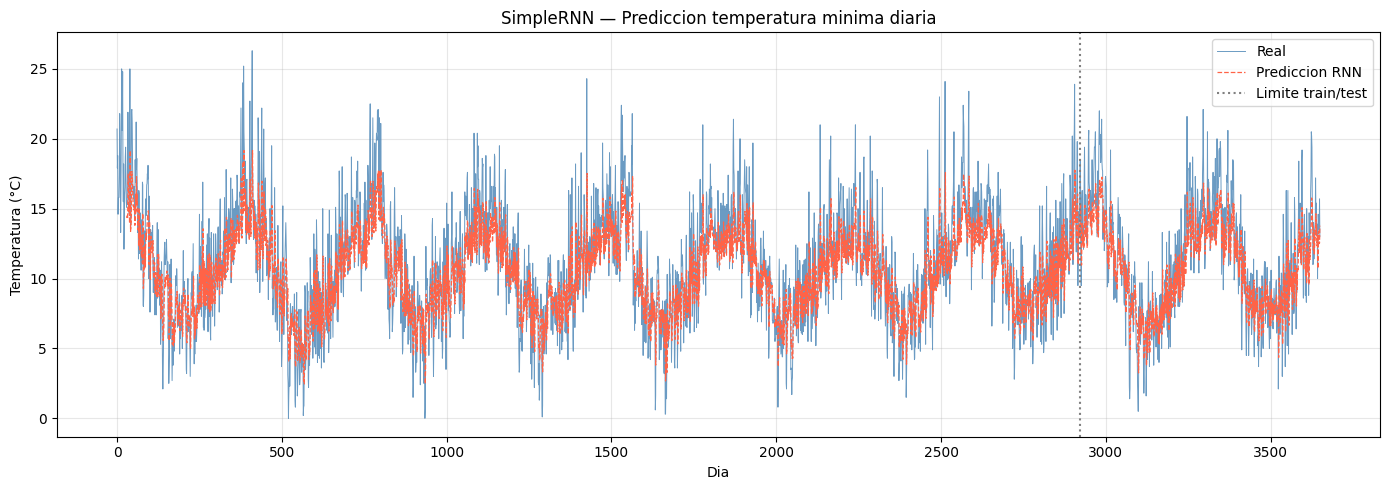

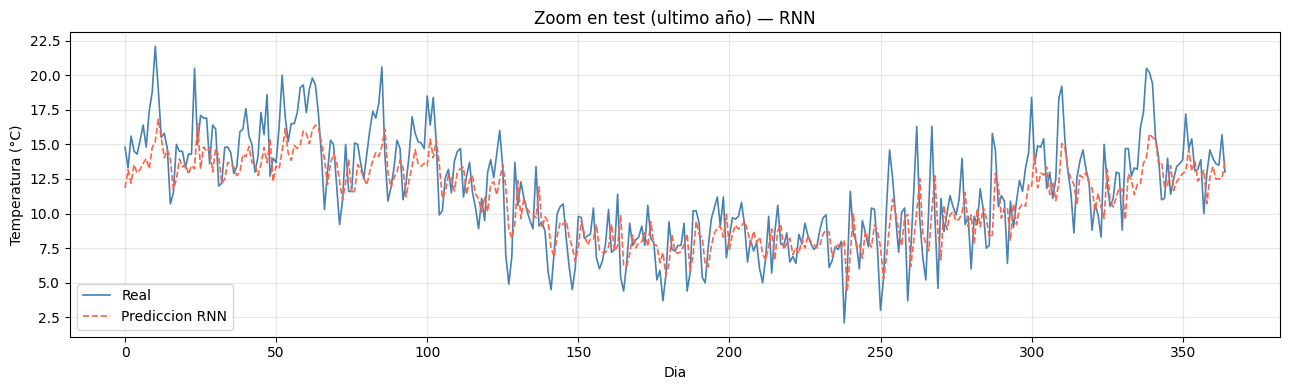

In [8]:
# 6) Evaluacion: prediccion vs. realidad

y_train_pred = model.predict(X_train, verbose=0)
y_test_pred  = model.predict(X_test,  verbose=0)

# Desnormalizamos: volvemos a grados Celsius
y_train_pred_inv = scaler.inverse_transform(y_train_pred)
y_test_pred_inv  = scaler.inverse_transform(y_test_pred)
y_train_inv      = scaler.inverse_transform(y_train)
y_test_inv       = scaler.inverse_transform(y_test)

mae_test  = mean_absolute_error(y_test_inv, y_test_pred_inv)
rmse_test = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))

print(f"MAE  (test): {mae_test:.2f}°C de error medio")
print(f"RMSE (test): {rmse_test:.2f}°C")
print(f"\nNota el MAE de la RNN — la LSTM deberia mejorarlo.")

# Grafico completo
full_pred = np.empty_like(temps)
full_pred[:] = np.nan
full_pred[WINDOW_SIZE:train_size] = y_train_pred_inv.flatten()
full_pred[train_size:train_size + len(y_test_pred_inv)] = y_test_pred_inv.flatten()

plt.figure(figsize=(14, 5))
plt.plot(temps,     label="Real",          color="steelblue", linewidth=0.7, alpha=0.8)
plt.plot(full_pred, label="Prediccion RNN", color="tomato",    linewidth=0.9, linestyle="--")
plt.axvline(x=train_size, color="gray", linestyle=":", linewidth=1.5, label="Limite train/test")
plt.title("SimpleRNN — Prediccion temperatura minima diaria")
plt.xlabel("Dia")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Zoom en los ultimos 365 dias del test para ver el detalle
n_zoom = min(365, len(y_test_inv))
plt.figure(figsize=(13, 4))
plt.plot(y_test_inv[-n_zoom:],      label="Real",           color="steelblue", linewidth=1.2)
plt.plot(y_test_pred_inv[-n_zoom:], label="Prediccion RNN", color="tomato",    linewidth=1.2, linestyle="--")
plt.title("Zoom en test (ultimo año) — RNN")
plt.xlabel("Dia")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

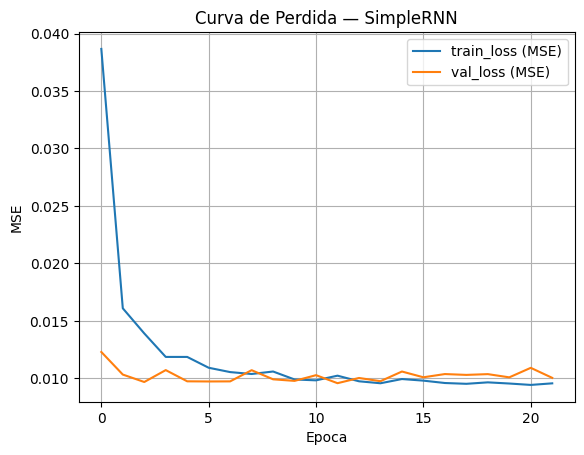

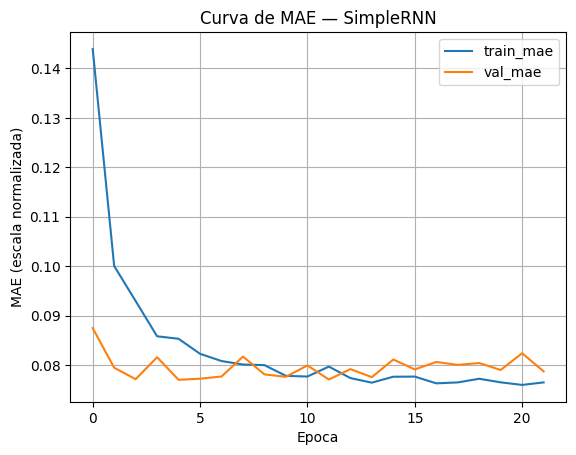

In [9]:
# 7) Curvas de aprendizaje
hist = history.history

plt.figure()
plt.plot(hist["loss"],     label="train_loss (MSE)")
plt.plot(hist["val_loss"], label="val_loss (MSE)")
plt.xlabel("Epoca")
plt.ylabel("MSE")
plt.title("Curva de Perdida — SimpleRNN")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist["mae"],     label="train_mae")
plt.plot(hist["val_mae"], label="val_mae")
plt.xlabel("Epoca")
plt.ylabel("MAE (escala normalizada)")
plt.title("Curva de MAE — SimpleRNN")
plt.legend()
plt.grid(True)
plt.show()

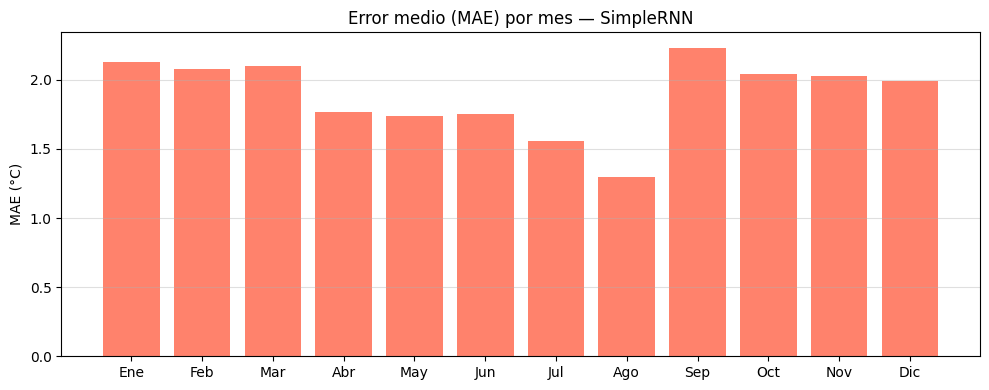

Mes con mayor error: Sep (2.23°C)

La SimpleRNN suele fallar mas en los meses de cambio de estacion
(primavera/otoño en hemisferio sur = Sep/Oct y Mar/Abr).
Ahi es donde necesita recordar el patron de semanas atras.
→ La LSTM lo mejorara en el siguiente notebook.


In [10]:
# 8) Analisis de errores: ¿donde falla mas la RNN?

errores = np.abs(y_test_inv.flatten() - y_test_pred_inv.flatten())

# Error por mes del año (para ver si falla mas en cambios de estacion)
# Aproximamos el mes: test empieza en el dia 2920 = Aug 1988 aprox.
dias_test = np.arange(len(errores))
mes_aprox = (dias_test % 365) // 30  # 0=ene, ..., 11=dic (aproximado)

error_por_mes = [errores[mes_aprox == m].mean() for m in range(12)]
nombres_meses = ["Ene","Feb","Mar","Abr","May","Jun",
                 "Jul","Ago","Sep","Oct","Nov","Dic"]

plt.figure(figsize=(10, 4))
plt.bar(nombres_meses, error_por_mes, color="tomato", alpha=0.8)
plt.title("Error medio (MAE) por mes — SimpleRNN")
plt.ylabel("MAE (°C)")
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

peor_mes_idx = np.argmax(error_por_mes)
print(f"Mes con mayor error: {nombres_meses[peor_mes_idx]} ({error_por_mes[peor_mes_idx]:.2f}°C)")
print()
print("La SimpleRNN suele fallar mas en los meses de cambio de estacion")
print("(primavera/otoño en hemisferio sur = Sep/Oct y Mar/Abr).")
print("Ahi es donde necesita recordar el patron de semanas atras.")
print("→ La LSTM lo mejorara en el siguiente notebook.")

## Resumen: ¿Que hemos aprendido?

| Concepto | Explicacion |
|---|---|
| **Serie temporal** | Datos donde el orden cronologico importa |
| **Split temporal** | Nunca aleatorio — siempre primeros N = train, ultimos M = test |
| **Ventana deslizante** | Convierte la serie en pares (X de 30 dias, y del dia 31) |
| **Normalizacion** | Fit del scaler solo sobre train, transform sobre test |
| **SimpleRNN** | Mantiene estado oculto h; sufre vanishing gradient con secuencias largas |
| **return_sequences** | True si apilamos RNN, False si viene Dense despues |

### ¿Que mejora la LSTM?

La LSTM añade un **cell state** (Cₜ) que actua como memoria larga, controlado por tres puertas:
- **Forget gate**: decide que olvidar del pasado
- **Input gate**: decide que guardar del presente
- **Output gate**: decide que parte de la memoria usar para predecir

Esto le permite retener el patron estacional de semanas atras sin que la señal se diluya.
El resultado: **menor MAE, especialmente en los meses de cambio de estacion**.

→ **Continua en el notebook 09 — LSTM Basico**